# Importing required Libraries

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import mean_absolute_error,accuracy_score
from imblearn.under_sampling import NearMiss


# Loading the dataset

In [36]:
data = pd.read_csv("../Datasets/titanic_toy.csv")
data

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


# Removing NaN Values by End of Distribution Technique

In [37]:
# End of distribution: mean + 3*std
for column in ['Age', 'Fare']:
    end_value = data[column].mean() + 3 * data[column].std()
    data[column] =data[column].fillna(end_value)


data


,Age,Fare,Family,Survived
0,22.00000,7.250000,1,0
1,38.00000,71.283300,1,1
2,26.00000,7.925000,0,1
3,35.00000,53.100000,1,1
4,35.00000,8.050000,0,0
...,...,...,...,...
886,27.00000,13.000000,0,0
887,19.00000,30.000000,0,1
888,73.27861,23.450000,3,0
889,26.00000,183.196725,0,1


# Plotting Survived Feature 

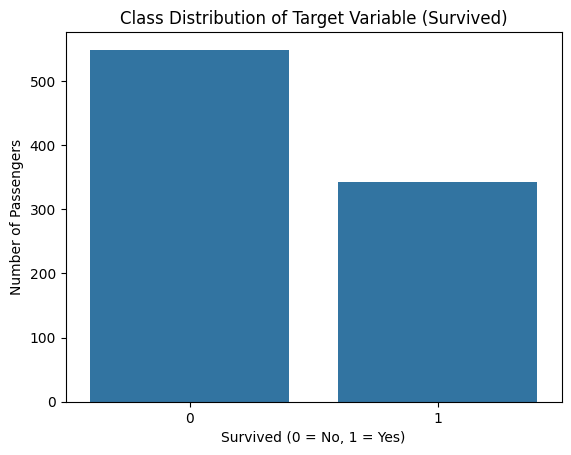

In [38]:
# Load the dataset (already loaded as 'df' if you've done this before)
# Count plot using seaborn
sns.countplot(x='Survived', data=data)
plt.title("Class Distribution of Target Variable (Survived)")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()


# NearMiss(Version-1)

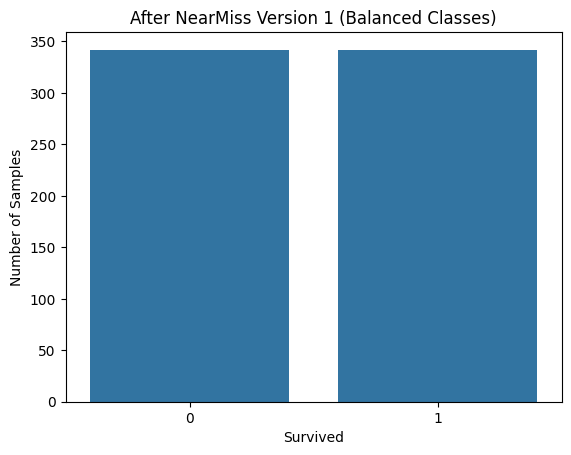

In [39]:
# Step 2: Separate features and target
X = data.drop('Survived', axis=1)
y = data['Survived']
nm1 = NearMiss(version=1)
X_res1, y_res1 = nm1.fit_resample(X, y)
sns.countplot(x=y_res1,data = data)
plt.title("After NearMiss Version 1 (Balanced Classes)")
plt.xlabel("Survived")
plt.ylabel("Number of Samples")
plt.show()
